In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#!pip install -U keras-tuner


# **1**. ENVIRONMENT

In [3]:
# Standard library
import os
import random

# data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pandas.plotting import scatter_matrix


# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import (
    GridSearchCV,
    learning_curve,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model, Input, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Hyperparameter tuning
#import keras_tuner as kt




## 1.1 Setting seeds

In [4]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## 1.2 Setting other variables

In [5]:
RUN_EXPENSIVE_CELLS = False

# Folder where there are all the results (.png format)
folder = "/content/drive/MyDrive/Secondo_Progetto_AI/Results/"

baseline_results=dict()
log_model_standard_threshold_results=dict()
dt_model_standard_threshold_results=dict()
random_forest_standard_threshold_results=dict()
dense_network_standard_threshold_results = dict()

log_model_best_threshold_results=dict()
dt_model_best_threshold_results=dict()
random_forest_best_threshold_results=dict()
dense_network_best_threshold_results = dict()

# dictionaries that contains all the 4 dictionaries above (used to convert from dict to dataframe in section 9)
standard_threshold_results = dict()
best_threshold_results = dict()


# **2**. IMPORT THE DATASET


In [6]:
df_original = pd.read_csv("/content/drive/MyDrive/Secondo_Progetto_AI/Datasets/dataset_purchase/online_shoppers_intention.csv")
df=df_original.copy()


print(df_original.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
df_original = pd.read_csv("/content/drive/MyDrive/Secondo_Progetto_AI/Datasets/dataset_purchase/online_shoppers_intention.csv")
df=df_original.copy()

#get the last columns (labels)
label_col = df.columns[-1]

#create a dataframe with just labels
df_labels=df[[label_col]]

#create a dataframe with just features
df_features = df.drop(columns=[label_col])

#df.describe()

# dataset loading, ready to be splitted
X, y = df_features.to_numpy(), df_labels.to_numpy()
y = y.reshape(-1)

In [8]:
display(df_original.head())
#print(df.describe())     # numerical stats

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# **3**. EDA

In [9]:
print(df_original.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## 3.1 Correlation between labels and features


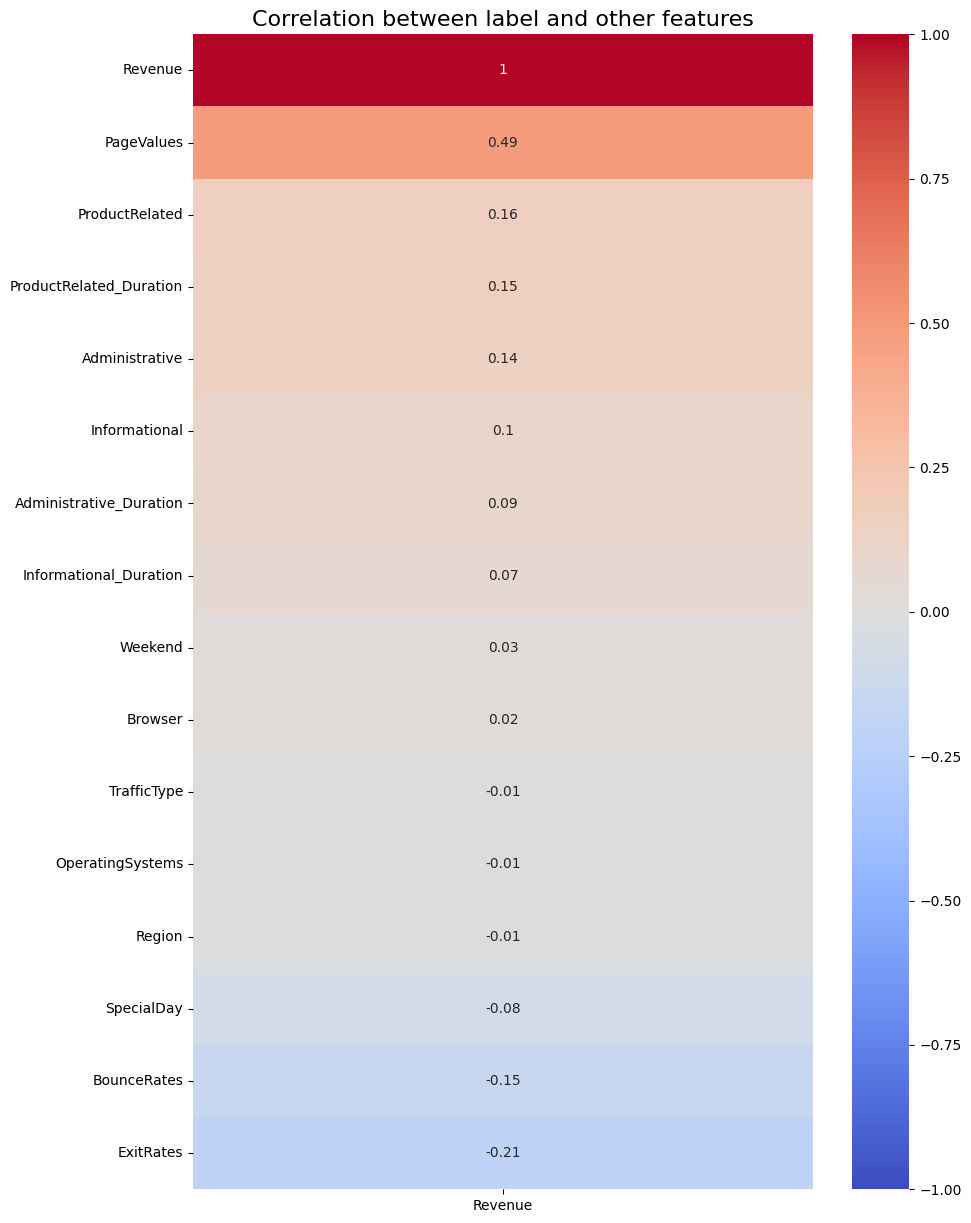

In [10]:
rounded_corr_matrix = df_original.corr(numeric_only=True).round(2)

plt.figure(figsize=(10, 15))

target_col = 'Revenue'

heatmap_data = rounded_corr_matrix[[target_col]].sort_values(by=target_col, ascending=False)

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm', #color map
    vmin=-1, vmax=1, #value min and max
    annot_kws={"size": 10} #font of the values
)

plt.title('Correlation between label and other features', fontsize=16)

plt.savefig(folder + "/correlation_matrix.png", dpi=300, bbox_inches='tight')


plt.show()

## 3.2 Class distribution

/tmp/ipython-input-142858502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='viridis')


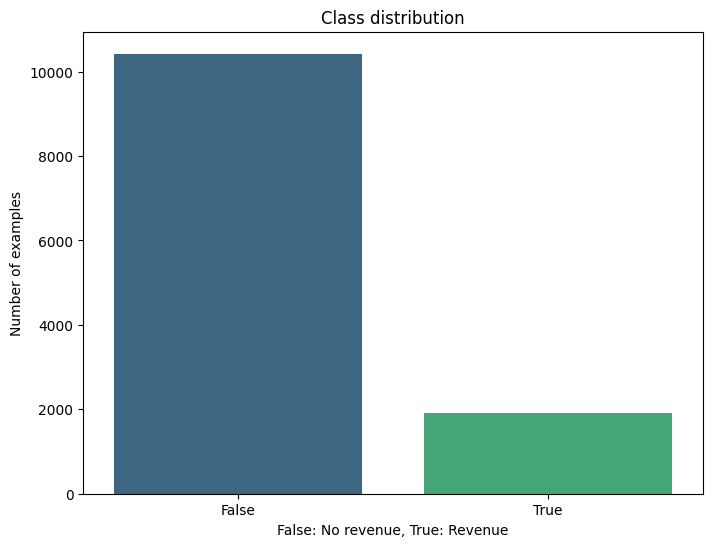

In [11]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Revenue', data=df, palette='viridis')

plt.title('Class distribution')
plt.xlabel('False: No revenue, True: Revenue')
plt.ylabel('Number of examples')
plt.savefig(folder+"/EDA/Class_distribution.png")
plt.show()

## 3.2 Feature distribution

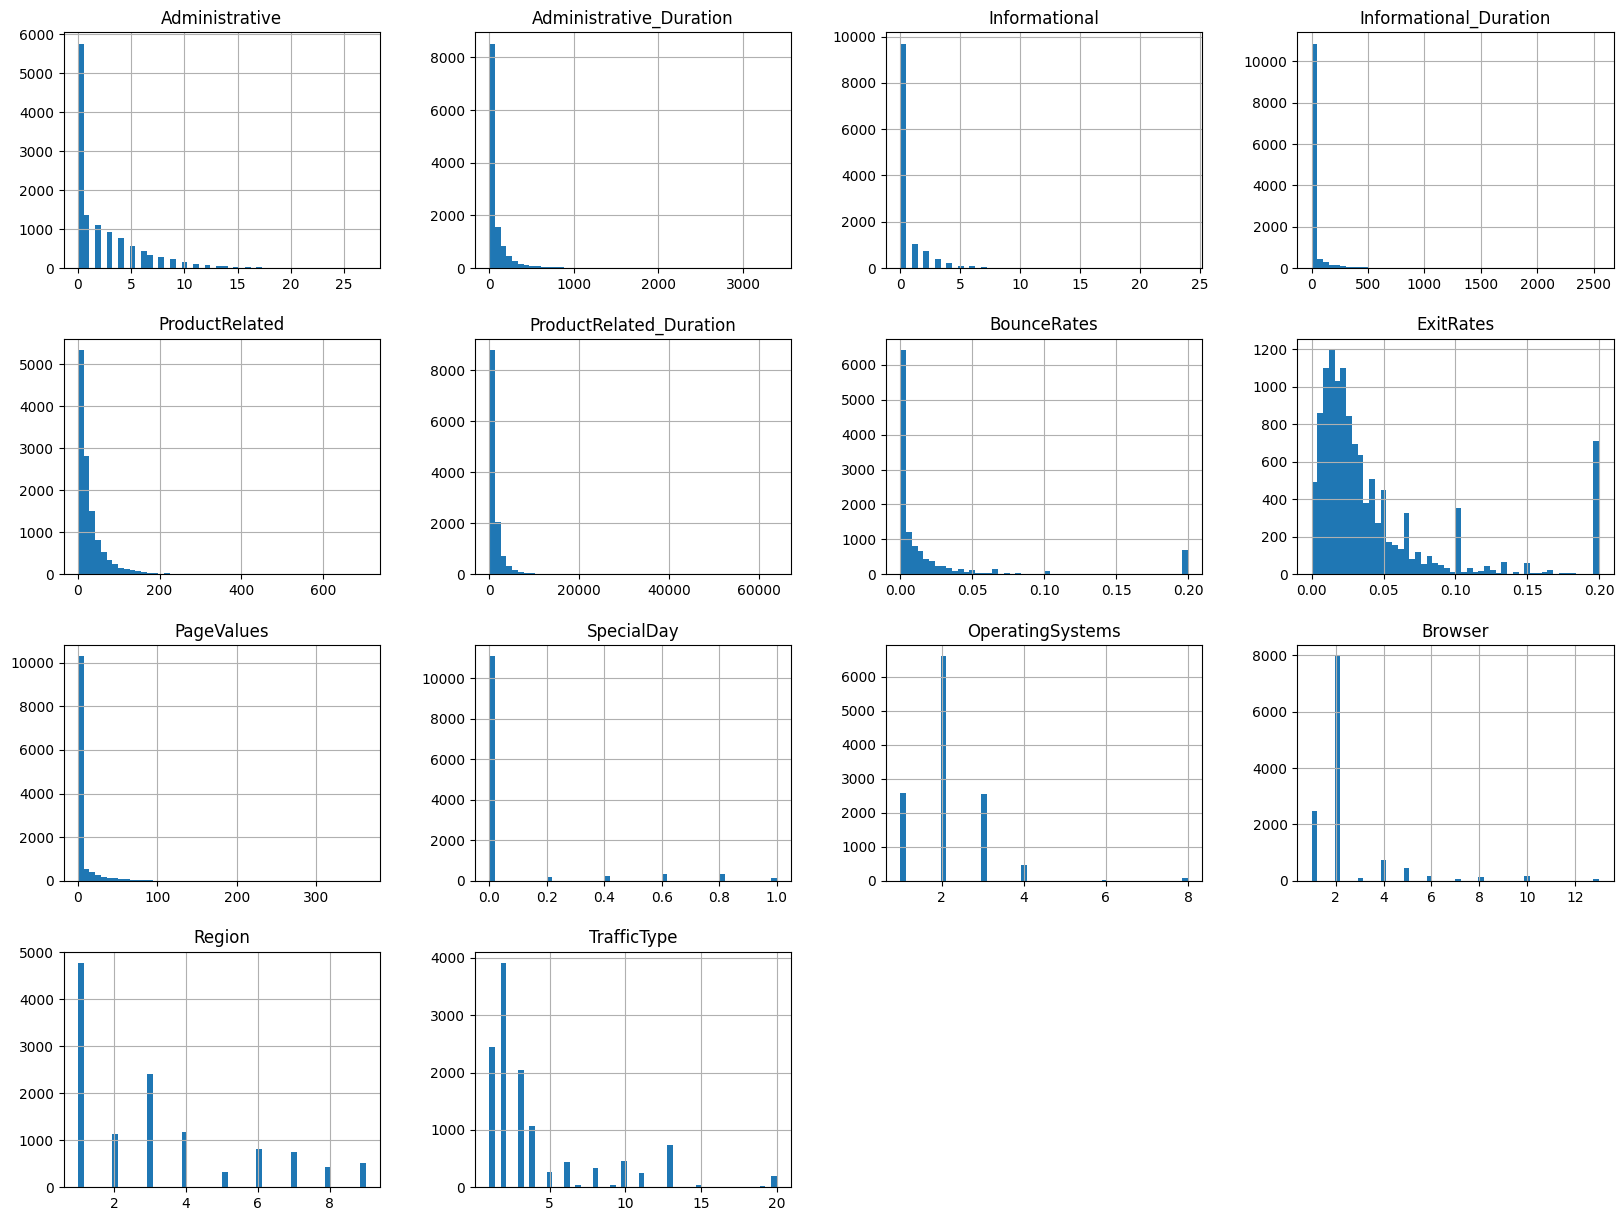

In [12]:
%matplotlib inline
df_original.hist(bins=50, figsize=(20,15))
plt.savefig(folder+"/EDA/Feature_distribution.png")
plt.show()

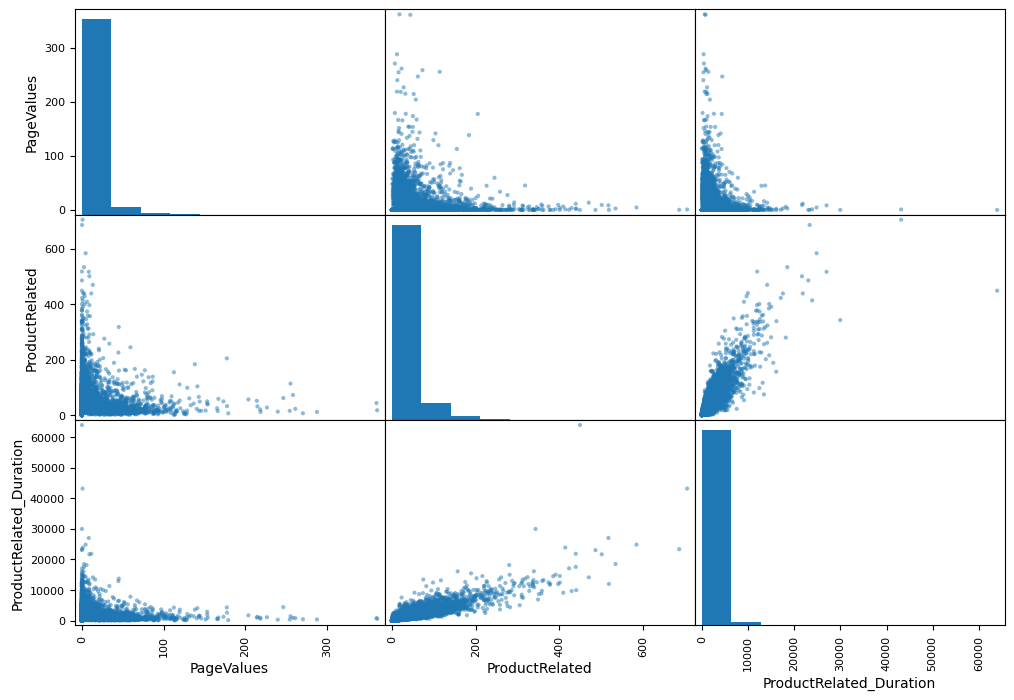

In [13]:
# Plot the most correlated features with label
attribues=["PageValues","ProductRelated","ProductRelated_Duration"]
scatter_matrix(df_original[attribues],figsize=(12,8))
plt.savefig(folder+"/EDA/Most_correlated_features_distribution.png")
plt.show()

# **4**.   PREPROCESSING THE DATASET


In [14]:
df_labels = df_labels.astype(int)
columns_to_remove = ['OperatingSystems', 'Browser','Region','TrafficType','Month','SpecialDay','VisitorType',
    'Weekend']
df_nuovo = df_features.drop(columns=columns_to_remove, axis=1)

In [15]:
# Split into training, test and validation
X_train, X_test, y_train, y_test = train_test_split(df_nuovo, df_labels, test_size=0.2, random_state=SEED)

In [16]:

# Selecting the columns to encode
numeric_columns = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
]



# creation of the preprocessor object of sklearn

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', MinMaxScaler(feature_range=(0, 1)), numeric_columns)
        ],
    remainder='passthrough' #Do not transform other columns

)


# ColumnTransformer gives in output NumPy array
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# we connect the numpy array obtained with the related new names of columns
new_feature_names = preprocessor.get_feature_names_out()

# Create dataframe again
df_train_processed = pd.DataFrame(X_train_processed, columns=new_feature_names)
df_test_processed = pd.DataFrame(X_test_processed, columns=new_feature_names)


#print("Nuove colonne:", df_processed.columns.tolist())


display(df_test_processed.head())
display(df_labels.head())


,scaler__Administrative,scaler__Administrative_Duration,scaler__Informational,scaler__Informational_Duration,scaler__ProductRelated,scaler__ProductRelated_Duration,scaler__BounceRates,scaler__ExitRates,scaler__PageValues
0,0.111111,0.041927,0.000000,0.000000,0.068085,0.016448,0.021739,0.065217,0.000000
1,0.222222,0.128692,0.083333,0.092395,0.117730,0.039139,0.010989,0.024581,0.005767
2,0.037037,0.012100,0.000000,0.000000,0.178723,0.067372,0.003439,0.064114,0.009540
3,0.074074,0.041486,0.000000,0.000000,0.014184,0.009483,0.041667,0.131944,0.101371
4,0.666667,0.178930,0.250000,0.287835,0.238298,0.077351,0.033159,0.067638,0.028059


,Revenue
0,0
1,0
2,0
3,0
4,0


# **5**.   BASELINE


In [17]:
counting = df['Revenue'].value_counts()
print(counting)

negatives = counting[0]
positives = counting[1]

TP = 0
FP = 0
TN = negatives
FN = positives

# Metrics
Accuracy = TN / (TN + FN)
Precision = 0.0  # Because TP=0
Recall = 0.0     # Because TP=0
F1_score = 0.0

baseline_results['accuracy'] = Accuracy
baseline_results['f1-score'] = F1_score
baseline_results['precision'] = Precision
baseline_results['recall'] = Recall

# put the results in the main dictionary
standard_threshold_results['Baseline'] = baseline_results
best_threshold_results['Baseline'] = baseline_results

print("\n\n--- RESULTS BASELINE (MAJORITY CLASS) ---")
print(f"f1-score:       {baseline_results['f1-score']:.4f}")
print(f"Precision:      {baseline_results['precision']:.4f}")
print(f"Recall:         {baseline_results['recall']:.4f}")
print(f"Accuracy :      {baseline_results['accuracy']:.4f}\n\n")

Revenue
False    10422
True      1908
Name: count, dtype: int64


--- RESULTS BASELINE (MAJORITY CLASS) ---
f1-score:       0.0000
Precision:      0.0000
Recall:         0.0000
Accuracy :      0.8453




/tmp/ipython-input-273663968.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  negatives = counting[0]
/tmp/ipython-input-273663968.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  positives = counting[1]


# **6**.   LOGISTIC


## 6.1 Train


In [18]:
# Logistic Regression model initialization
log_model = LogisticRegression(
    solver='liblinear',
    random_state=SEED,
    penalty='l2',
    C=1,
)

# model training
log_model.fit(X_train_processed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=1, random_state=42, solver='liblinear')

## 6.2 Evaluate

### 6.2.1 Learning curves

In [19]:
y_pred = log_model.predict(X_test_processed)

# getting accuracy, f1-score, precision and recall and putting them in the dictionary
log_model_standard_threshold_results['accuracy'] = accuracy_score(y_test,y_pred)
log_model_standard_threshold_results['f1-score'] = f1_score(y_test,y_pred)
log_model_standard_threshold_results['precision'] = precision_score(y_test,y_pred)
log_model_standard_threshold_results['recall'] = recall_score(y_test,y_pred)

# put the results in the main dictionary
standard_threshold_results['Logistic Regression']=log_model_standard_threshold_results

print("\n\n--- RESULTS LOGISTIC REGRESSION ---")
print(f"f1-score:       {log_model_standard_threshold_results['f1-score']:.4f}")
print(f"Precision:      {log_model_standard_threshold_results['precision']:.4f}")
print(f"Recall:         {log_model_standard_threshold_results['recall']:.4f}")
print(f"Accuracy :      {log_model_standard_threshold_results['accuracy']:.4f}")



--- RESULTS LOGISTIC REGRESSION ---
f1-score:       0.3898
Precision:      0.7754
Recall:         0.2603
Accuracy :      0.8642


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


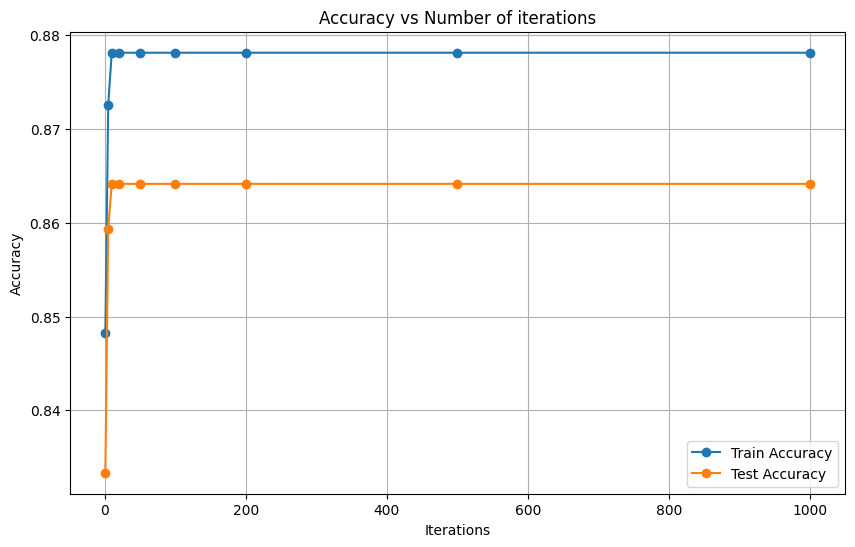

In [20]:
iterations = [1, 5, 10, 20, 50, 100, 200, 500, 1000]
train_acc = []
test_acc = []

for i in iterations:
    log_model = LogisticRegression(max_iter=i,
                               solver='liblinear',
                               random_state=SEED,
                               penalty='l2',
                               C=1,
                               warm_start=True)

    log_model.fit(X_train_processed, y_train.values.ravel())

    train_acc.append(accuracy_score(y_train, log_model.predict(X_train_processed)))
    test_acc.append(accuracy_score(y_test, log_model.predict(X_test_processed)))

plt.figure(figsize=(10, 6))
#plt.axhline(y=baseline_results['accuracy'], color='r', linestyle='--', label='Baseline')
plt.plot(iterations, train_acc, label='Train Accuracy', marker='o')
plt.plot(iterations, test_acc, label='Test Accuracy', marker='o')

plt.title('Accuracy vs Number of iterations')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(folder+"/Logistic_regression/Accuracy_vs_Iterations.png")
plt.show()

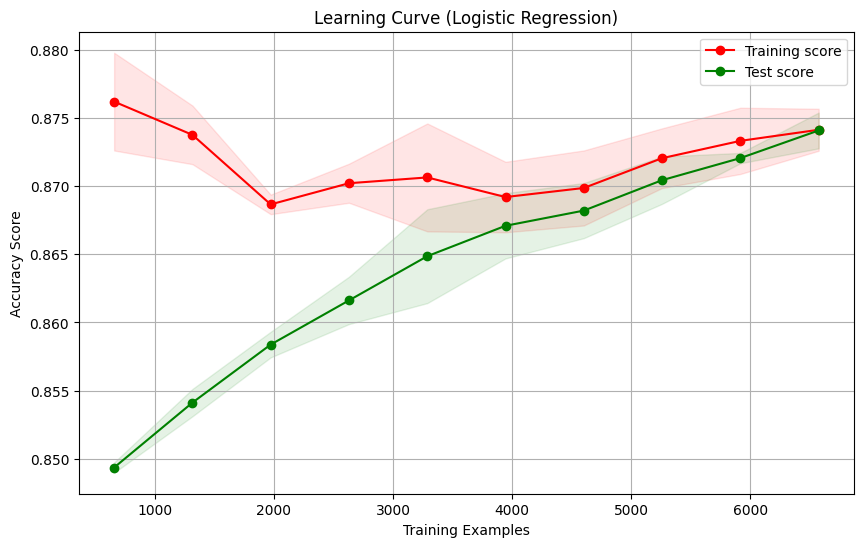

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression


train_sizes, train_scores, test_scores = learning_curve(
    log_model, X_train_processed, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=SEED,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)


train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
#plt.axhline(y=baseline_results['accuracy'], color='r', linestyle='--', label='Baseline')


plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")

plt.plot(train_sizes, test_mean, 'o-', color="g", label="Test score")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve (Logistic Regression)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.savefig(folder+"/Logistic_regression/Learning_curve_Logistic_Regression.png")
plt.show()

### 6.2.2 Confusion Matrix

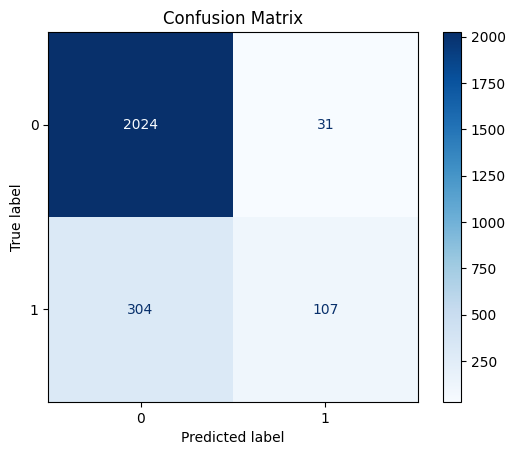

In [22]:
# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred, # using the best set of predictions
    #display_labels=["Not Malware", "Malware"],
    cmap=plt.cm.Blues
)

disp.ax_.set_title("Confusion Matrix")
plt.savefig(folder+"/Logistic_regression/Confusion_Matrix.png")
plt.show()


## 6.3 Evaluate with best Threshold


In [23]:
y_probs = log_model.predict_proba(X_test_processed)[:, 1]

thresholds = np.linspace(0, 1, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_score = f1_scores[best_idx]

# getting best f1-score and put in the dictionary
best_f1_score = max(f1_scores)

print("--- RESULTS FROM THRESHOLD OPTIMIZATION ---")
print(f"\nF1-score:       {log_model_standard_threshold_results['f1-score']:.4f}    at threshold = 0.5")
print(f"Best F1-score:  {best_f1_score:.4f}    at threshold = {best_threshold:.2f}")

--- RESULTS FROM THRESHOLD OPTIMIZATION ---

F1-score:       0.3898    at threshold = 0.5
Best F1-score:  0.6350    at threshold = 0.18


In [24]:
#getting the best predictions
y_pred_best= (log_model.predict_proba(X_test_processed)[:,1]>=best_threshold).astype(int)

# getting accuracy, f1-score, precision and recall and putting them in the dictionary
log_model_best_threshold_results['accuracy'] = accuracy_score(y_test,y_pred_best)
log_model_best_threshold_results['f1-score'] = f1_score(y_test,y_pred_best)
log_model_best_threshold_results['precision'] = precision_score(y_test,y_pred_best)
log_model_best_threshold_results['recall'] = recall_score(y_test,y_pred_best)

# put the results in the main dictionary
best_threshold_results['Logistic Regression']=log_model_best_threshold_results

print("\n\n--- RESULTS LOGISTIC REGRESSION WITH BEST THRESHOLD ---")
print(f"f1-score:       {log_model_best_threshold_results['f1-score']:.4f}")
print(f"Precision:      {log_model_best_threshold_results['precision']:.4f}")
print(f"Recall:         {log_model_best_threshold_results['recall']:.4f}")
print(f"Accuracy :      {log_model_best_threshold_results['accuracy']:.4f}")



--- RESULTS LOGISTIC REGRESSION WITH BEST THRESHOLD ---
f1-score:       0.6350
Precision:      0.5822
Recall:         0.6983
Accuracy :      0.8662


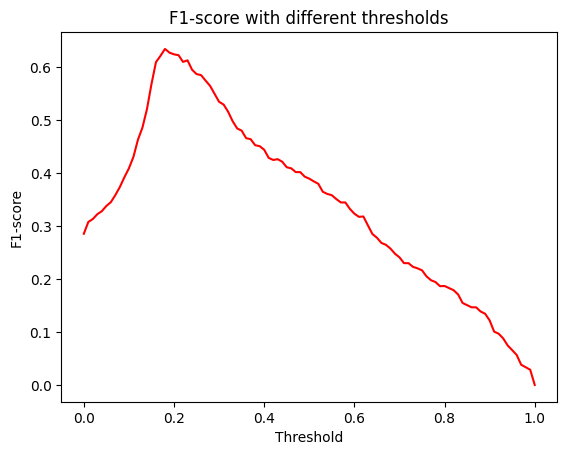

In [25]:
# Plot of the curve of the f1-score with respect to the different thresholds:
plt.plot(thresholds, f1_scores, "r")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score with different thresholds")
plt.savefig(folder+"/Logistic_regression/F1-score_curve.png")
plt.show()


# **7**. DECISION TREE CLASSIFIER


## 7.1 Train

In [26]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=SEED
)

dt_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

## 7.2 Evaluate

In [27]:
y_pred_prob = dt_model.predict(X_test_processed)  # array of probabilities
y_pred = (y_pred_prob >= 0.5).astype(int)  # making predictions with the probabilities


# getting accuracy, f1-score, precision and recall and putting them in the dictionary
dt_model_standard_threshold_results['accuracy'] = accuracy_score(y_test,y_pred)
dt_model_standard_threshold_results['f1-score'] = f1_score(y_test,y_pred)
dt_model_standard_threshold_results['precision'] = precision_score(y_test,y_pred)
dt_model_standard_threshold_results['recall'] = recall_score(y_test,y_pred)

# put the results in the main dictionary
standard_threshold_results['Decision tree']=dt_model_standard_threshold_results

print("\n\n--- RESULTS DECISION TREE ---")
print(f"f1-score:       {dt_model_standard_threshold_results['f1-score']:.4f}")
print(f"Precision:      {dt_model_standard_threshold_results['precision']:.4f}")
print(f"Recall:         {dt_model_standard_threshold_results['recall']:.4f}")
print(f"Accuracy :      {dt_model_standard_threshold_results['accuracy']:.4f}")



--- RESULTS DECISION TREE ---
f1-score:       0.6016
Precision:      0.6677
Recall:         0.5474
Accuracy :      0.8792


<Figure size 3000x4000 with 0 Axes>

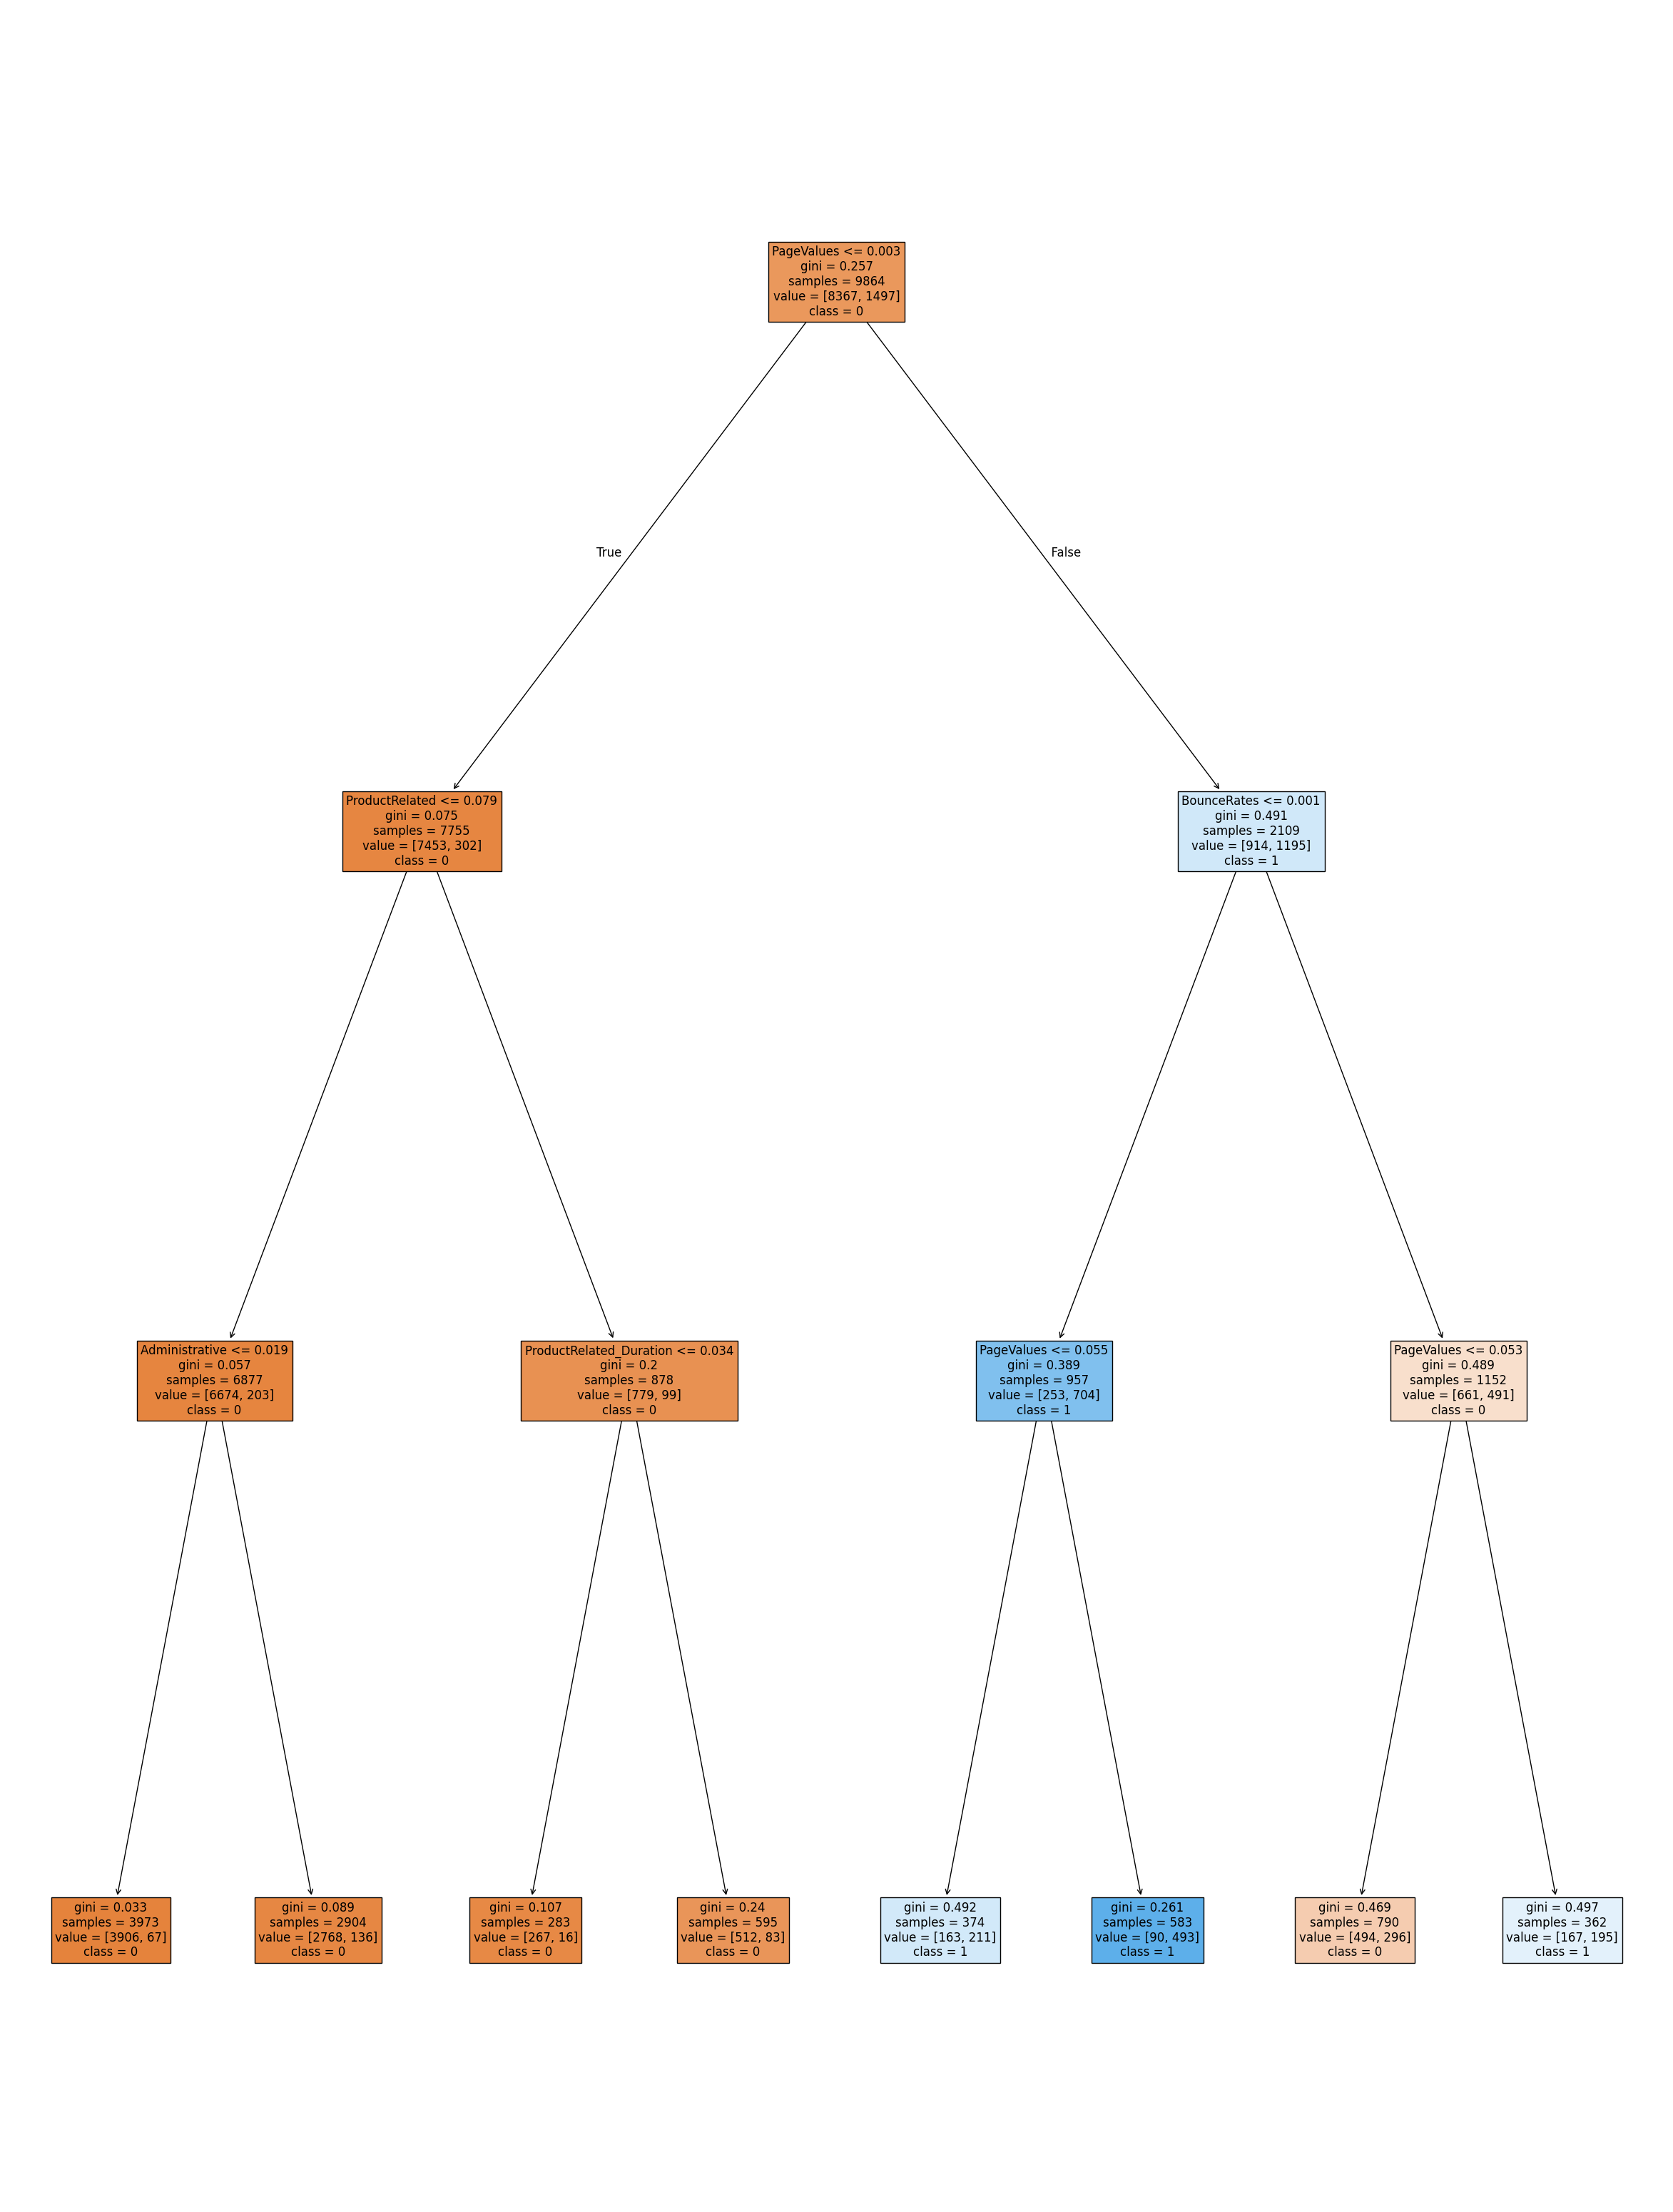

In [28]:
# Plot the decision Tree
tree_0 = dt_model.tree_

feature_names=list(df_features.columns)

class_names=[]
for i in dt_model.classes_:
    class_names.append(str(i))

plt.figure(figsize=(30, 40))

plt.figure(figsize=(30, 40))
tree.plot_tree(
     dt_model,
     feature_names=feature_names,
     class_names=class_names,
     max_depth=3,
     filled=True,
     fontsize=12
)
plt.savefig(folder + "/Decision_tree_classifier/Decision_tree_example.png", dpi=300)
plt.show()

## 7.3 Learning curve

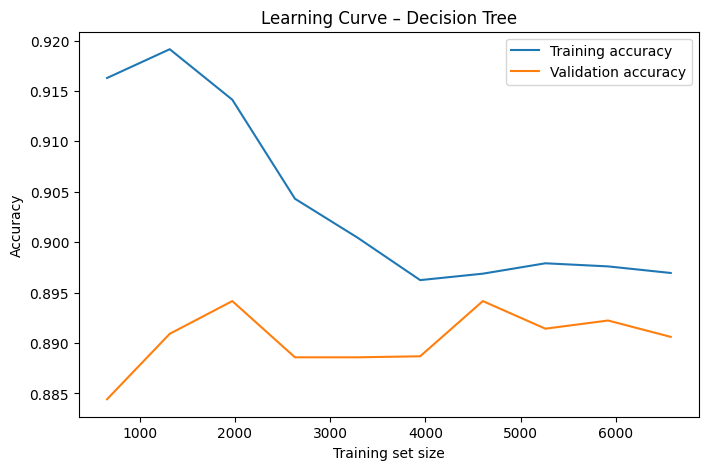

In [29]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=dt_model,
    X=X_train_processed,
    random_state=SEED,
    y=y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10), # gradually increase the size of data for training
    cv=3,
    scoring="accuracy"
)



train_mean = np.mean(train_scores, axis=1) # mean of train_acc from the 5-fold validation (10 points)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1) # mean of val_acc from the 5-fold validation (10 points)
val_std = np.std(val_scores, axis=1)


plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, label="Training accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Decision Tree")
plt.savefig(folder + "/Decision_tree_classifier/Learning_curve_Decision_tree.png", dpi=300)
plt.legend()

## 7.4 Evaluate with best Threshold

In [30]:
y_probs = dt_model.predict_proba(X_test_processed)[:, 1]

thresholds = np.linspace(0, 1, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_score = f1_scores[best_idx]

# getting best f1-score and put in the dictionary
best_f1_score = max(f1_scores)

print("--- RESULTS FROM THRESHOLD OPTIMIZATION ---")
print(f"\nF1-score:       {dt_model_standard_threshold_results['f1-score']:.4f}    at threshold = 0.5")
print(f"Best F1-score:  {best_f1_score:.4f}    at threshold = {best_threshold:.2f}")

--- RESULTS FROM THRESHOLD OPTIMIZATION ---

F1-score:       0.6016    at threshold = 0.5
Best F1-score:  0.6743    at threshold = 0.14


In [31]:
#getting the best predictions
y_pred_best= (dt_model.predict_proba(X_test_processed)[:,1]>=best_threshold).astype(int)

# getting accuracy, f1-score, precision and recall and putting them in the dictionary
dt_model_best_threshold_results['accuracy'] = accuracy_score(y_test,y_pred_best)
dt_model_best_threshold_results['f1-score'] = f1_score(y_test,y_pred_best)
dt_model_best_threshold_results['precision'] = precision_score(y_test,y_pred_best)
dt_model_best_threshold_results['recall'] = recall_score(y_test,y_pred_best)

# put the results in the main dictionary
best_threshold_results['Decision tree']=dt_model_best_threshold_results

print("\n\n--- RESULTS DECISION TREE WITH BEST THRESHOLD ---")
print(f"f1-score:       {dt_model_best_threshold_results['f1-score']:.4f}")
print(f"Precision:      {dt_model_best_threshold_results['precision']:.4f}")
print(f"Recall:         {dt_model_best_threshold_results['recall']:.4f}")
print(f"Accuracy :      {dt_model_best_threshold_results['accuracy']:.4f}")



--- RESULTS DECISION TREE WITH BEST THRESHOLD ---
f1-score:       0.6743
Precision:      0.5863
Recall:         0.7932
Accuracy :      0.8723


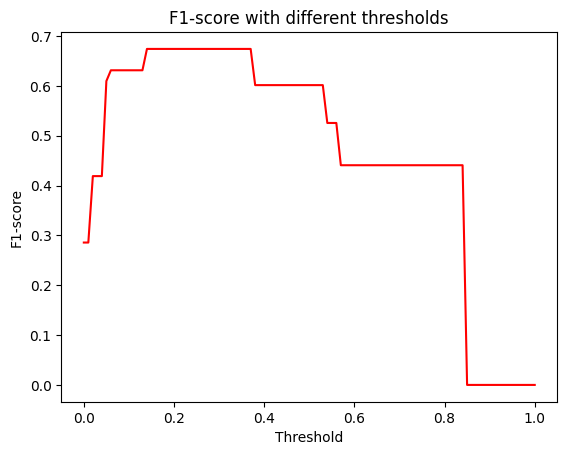

In [32]:
# Plot of the curve of the f1-score with respect to the different thresholds:
plt.plot(thresholds, f1_scores, "r")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score with different thresholds")
plt.savefig(folder+"/Decision_tree_classifier/F1-score_curve.png")
plt.show()


## 7.5 Confusion Matrix

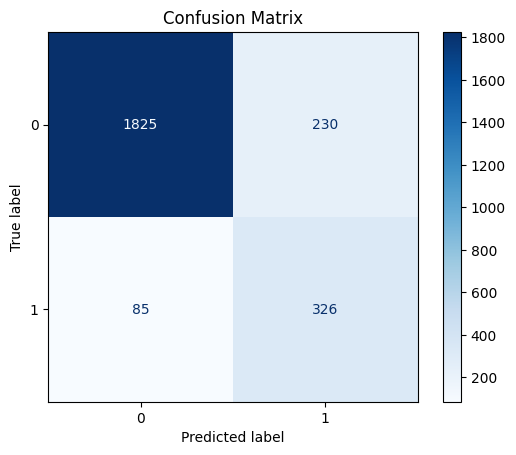

In [33]:
# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best, # using the best set of predictions
    cmap=plt.cm.Blues
)

disp.ax_.set_title("Confusion Matrix")
plt.savefig(folder+"/Decision_tree_classifier/Confusion_Matrix.png")
plt.show()


In [34]:
print(standard_threshold_results)
print(best_threshold_results)

{'Baseline': {'accuracy': np.float64(0.8452554744525548), 'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0}, 'Logistic Regression': {'accuracy': 0.8641524736415247, 'f1-score': 0.38979963570127507, 'precision': 0.7753623188405797, 'recall': 0.26034063260340634}, 'Decision tree': {'accuracy': 0.8791565287915653, 'f1-score': 0.6016042780748663, 'precision': 0.6676557863501483, 'recall': 0.5474452554744526}}
{'Baseline': {'accuracy': np.float64(0.8452554744525548), 'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0}, 'Logistic Regression': {'accuracy': 0.8661800486618005, 'f1-score': 0.6349557522123894, 'precision': 0.5821501014198783, 'recall': 0.6982968369829684}, 'Decision tree': {'accuracy': 0.8722627737226277, 'f1-score': 0.6742502585315409, 'precision': 0.5863309352517986, 'recall': 0.7931873479318735}}


# **8**.  RANDOM FOREST

## 8.1 Train


In [35]:
rf_model = RandomForestClassifier(
    n_estimators= 300,
    random_state=SEED,
    max_depth= 3,
    max_features='sqrt',
    min_samples_leaf= 10,
)

rf_model.fit(X_train_processed, y_train.values.ravel())




RandomForestClassifier(max_depth=3, min_samples_leaf=10, n_estimators=300,
                       random_state=42)

## 8.2 Evaluate

In [36]:
y_pred = rf_model.predict(X_test_processed)


# getting accuracy, f1-score, precision and recall and putting them in the dictionary
random_forest_standard_threshold_results['accuracy'] = accuracy_score(y_test,y_pred)
random_forest_standard_threshold_results['f1-score'] = f1_score(y_test,y_pred)
random_forest_standard_threshold_results['precision'] = precision_score(y_test,y_pred)
random_forest_standard_threshold_results['recall'] = recall_score(y_test,y_pred)

# put the results in the main dictionary
standard_threshold_results['Random forest']=random_forest_standard_threshold_results

print("\n\n--- RESULTS RANDOM FOREST ---")
print(f"f1-score:       {random_forest_standard_threshold_results['f1-score']:.4f}")
print(f"Precision:      {random_forest_standard_threshold_results['precision']:.4f}")
print(f"Recall:         {random_forest_standard_threshold_results['recall']:.4f}")
print(f"Accuracy :      {random_forest_standard_threshold_results['accuracy']:.4f}")





--- RESULTS RANDOM FOREST ---
f1-score:       0.4842
Precision:      0.8679
Recall:         0.3358
Accuracy :      0.8808


In [37]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                   Feature  Importance
8               PageValues    0.683602
7                ExitRates    0.123111
5  ProductRelated_Duration    0.076044
6              BounceRates    0.050880
4           ProductRelated    0.029405
0           Administrative    0.019203
1  Administrative_Duration    0.013696
3   Informational_Duration    0.002631
2            Informational    0.001428


## 8.3 Learning curve


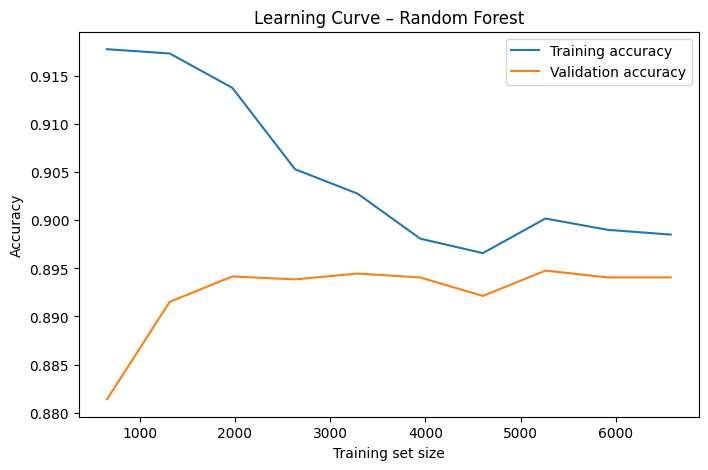

In [38]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_model,
    X=X_train_processed,
    random_state=SEED,
    y=y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10), # gradually increase the size of data for training
    cv=3,
    scoring="accuracy"
)

train_mean = np.mean(train_scores, axis=1) # mean of train_acc from the 5-fold validation (10 points)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1) # mean of val_acc from the 5-fold validation (10 points)
val_std = np.std(val_scores, axis=1)


plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, label="Training accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Random Forest")
plt.savefig(folder+"/Random_forest/Learning_curve_Random_forest.png")
plt.legend()

## 8.4 Evaluate with best Threshold

In [39]:
y_probs = rf_model.predict_proba(X_test_processed)[:, 1]

thresholds = np.linspace(0, 1, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_score = f1_scores[best_idx]

# getting best f1-score and put in the dictionary
best_f1_score = max(f1_scores)

print("--- RESULTS FROM THRESHOLD OPTIMIZATION ---")
print(f"\nF1-score:       {random_forest_standard_threshold_results['f1-score']:.4f}    at threshold = 0.5")
print(f"Best F1-score:  {best_f1_score:.4f}    at threshold = {best_threshold:.2f}")

--- RESULTS FROM THRESHOLD OPTIMIZATION ---

F1-score:       0.4842    at threshold = 0.5
Best F1-score:  0.6780    at threshold = 0.31


In [40]:
#getting the best predictions
y_pred_best= (rf_model.predict_proba(X_test_processed)[:,1]>=best_threshold).astype(int)

# getting accuracy, f1-score, precision and recall and putting them in the dictionary
random_forest_best_threshold_results['accuracy'] = accuracy_score(y_test,y_pred_best)
random_forest_best_threshold_results['f1-score'] = f1_score(y_test,y_pred_best)
random_forest_best_threshold_results['precision'] = precision_score(y_test,y_pred_best)
random_forest_best_threshold_results['recall'] = recall_score(y_test,y_pred_best)

# put the results in the main dictionary
best_threshold_results['Random forest']=random_forest_best_threshold_results

print("\n\n--- RESULTS RANDOM FOREST WITH BEST THRESHOLD ---")
print(f"f1-score:       {random_forest_best_threshold_results['f1-score']:.4f}")
print(f"Precision:      {random_forest_best_threshold_results['precision']:.4f}")
print(f"Recall:         {random_forest_best_threshold_results['recall']:.4f}")
print(f"Accuracy :      {random_forest_best_threshold_results['accuracy']:.4f}")



--- RESULTS RANDOM FOREST WITH BEST THRESHOLD ---
f1-score:       0.6780
Precision:      0.6034
Recall:         0.7737
Accuracy :      0.8775


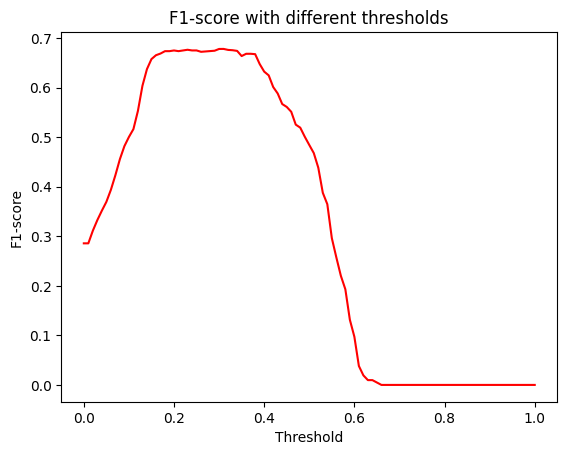

In [41]:
# Plot of the curve of the f1-score with respect to the different thresholds:
plt.plot(thresholds, f1_scores, "r")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score with different thresholds")
plt.savefig(folder+"/Random_forest/F1-score_curve.png")
plt.show()


## 8.5 Confusion Matrix

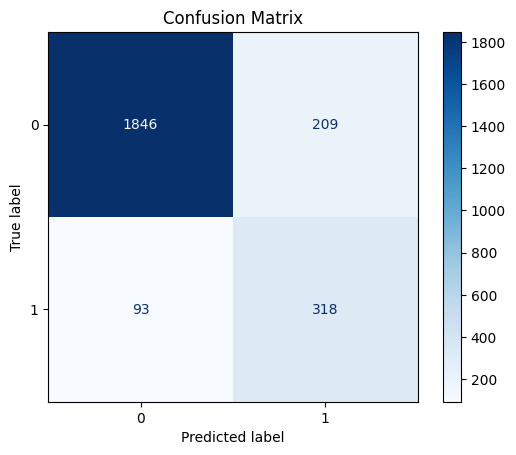

In [42]:
# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best, # using the best set of predictions
    cmap=plt.cm.Blues
)

disp.ax_.set_title("Confusion Matrix")
plt.savefig(folder+"/Random_forest/Confusion_Matrix.png")
plt.show()


In [43]:
print(standard_threshold_results)
print(best_threshold_results)

{'Baseline': {'accuracy': np.float64(0.8452554744525548), 'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0}, 'Logistic Regression': {'accuracy': 0.8641524736415247, 'f1-score': 0.38979963570127507, 'precision': 0.7753623188405797, 'recall': 0.26034063260340634}, 'Decision tree': {'accuracy': 0.8791565287915653, 'f1-score': 0.6016042780748663, 'precision': 0.6676557863501483, 'recall': 0.5474452554744526}, 'Random forest': {'accuracy': 0.8807785888077859, 'f1-score': 0.4842105263157895, 'precision': 0.8679245283018868, 'recall': 0.3357664233576642}}
{'Baseline': {'accuracy': np.float64(0.8452554744525548), 'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0}, 'Logistic Regression': {'accuracy': 0.8661800486618005, 'f1-score': 0.6349557522123894, 'precision': 0.5821501014198783, 'recall': 0.6982968369829684}, 'Decision tree': {'accuracy': 0.8722627737226277, 'f1-score': 0.6742502585315409, 'precision': 0.5863309352517986, 'recall': 0.7931873479318735}, 'Random forest': {'accuracy': 0.877534

# **9**.   NEURAL NETWORK



## **9.1**.   PREPROCESSING FOR NN


In [44]:
# Split into training, test and validation
X_train, X_temp, y_train, y_temp = train_test_split(df_nuovo, df_labels, test_size=0.2, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

In [45]:

# Selecting the columns to encode
numeric_columns = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
]



# creation of the preprocessor object of sklearn

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', MinMaxScaler(feature_range=(0, 1)), numeric_columns)
        ],
    remainder='passthrough' #Do not transform other columns

)


# ColumnTransformer gives in output NumPy array
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# we connect the numpy array obtained with the related new names of columns
new_feature_names = preprocessor.get_feature_names_out()

# Create dataframe again
df_train_processed = pd.DataFrame(X_train_processed, columns=new_feature_names)
df_test_processed = pd.DataFrame(X_test_processed, columns=new_feature_names)


#print("Nuove colonne:", df_processed.columns.tolist())


display(df_test_processed.head())
display(df_labels.head())


,scaler__Administrative,scaler__Administrative_Duration,scaler__Informational,scaler__Informational_Duration,scaler__ProductRelated,scaler__ProductRelated_Duration,scaler__BounceRates,scaler__ExitRates,scaler__PageValues
0,0.000000,0.000000,0.000000,0.000000,0.126241,0.054410,0.011236,0.073502,0.0
1,0.074074,0.017948,0.000000,0.000000,0.007092,0.001516,0.000000,0.200000,0.0
2,0.000000,0.000000,0.000000,0.000000,0.034043,0.014335,0.041667,0.159722,0.0
3,0.037037,0.023832,0.000000,0.000000,0.017021,0.002056,0.000000,0.015385,0.0
4,0.148148,0.076204,0.041667,0.016475,0.025532,0.006283,0.000000,0.085526,0.0


,Revenue
0,0
1,0
2,0
3,0
4,0


In [46]:
input_shape= (X_train_processed.shape[1],)
print(input_shape)
epochs = range(1, 51)

LEARNING_RATE=0.001
BATCH_SIZE=32

(9,)


## 9.2 Overfitted Model


In [47]:
def build_model_1(input_shape):
  inputs=Input(input_shape)
  x = Dense(units=64, activation='relu')(inputs)
  x = Dense(units=32, activation="relu")(x)
  x = Dense(units=16, activation="relu")(x)
  outputs = Dense(units=1, activation="sigmoid")(x)
  return Model(inputs=inputs, outputs=outputs)





### 9.2.1 Train

In [48]:
dense_model_1 = build_model_1(input_shape=input_shape)

dense_model_1.summary()

dense_model_1.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

history = dense_model_1.fit(
    X_train_processed, y_train,
    epochs=len(epochs),
    verbose=1,
    validation_data=(X_test_processed,y_test),
    batch_size=BATCH_SIZE
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8352 - loss: 0.4698 - val_accuracy: 0.8686 - val_loss: 0.3178
Epoch 2/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8886 - loss: 0.2827 - val_accuracy: 0.8816 - val_loss: 0.2897
Epoch 3/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8974 - loss: 0.2665 - val_accuracy: 0.8832 - val_loss: 0.2852
Epoch 4/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8980 - loss: 0.2616 - val_accuracy: 0.8832 - val_loss: 0.2827
Epoch 5/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8993 - loss: 0.2589 - val_accuracy: 0.8824 - val_loss: 0.2809
Epoch 6/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9019 - loss: 0.2569 - val_accuracy: 0.8856 - val_loss: 0.2799
Epoch 7/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9025 - loss: 0.2556 - val_accuracy: 0.8832 - val_loss: 0.2786
Epoch 8/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9025 - loss: 0.2542 - val_accuracy: 0.

### 8.2.2 Evaluate

In [49]:
test_loss, test_acc = dense_model_1.evaluate(X_test_processed, y_test)
print(f"Loss after the test:{test_loss}\nAccuracy after the test:{test_acc}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8778 - loss: 0.2842
Loss after the test:0.2729291617870331
Accuracy after the test:0.8832116723060608


### 9.2.3 Learning curves



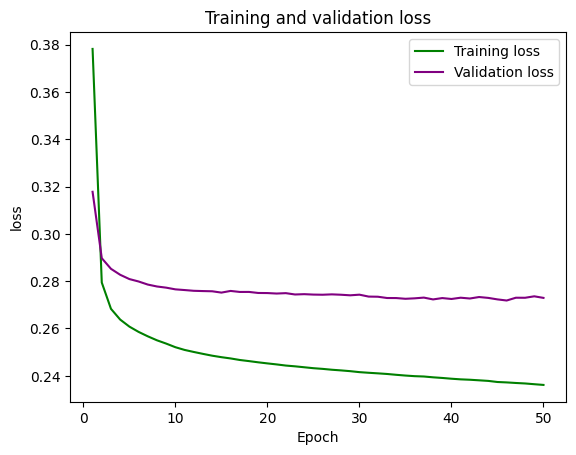

<Figure size 640x480 with 0 Axes>

In [50]:
#history
results = history.history
accuracy= results['accuracy']
val_accuracy= results['val_accuracy']
loss= results['loss']
val_loss= results['val_loss']


#loss
plt.plot(epochs,loss,"g",label="Training loss")
plt.plot(epochs,val_loss,"purple",label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.legend(loc="best")
plt.savefig(folder + "Dense_neural_network/Overfitted_model/Train_val_loss.png")
plt.show()
plt.clf()


## 9.3 Light Model


In [51]:
def model_2(input_shape):
  inputs=Input(input_shape)
  x = Dense(units=16, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4))(inputs)
  x = Dense(units=4, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4))(x)
  outputs = Dense(units=1, activation="sigmoid")(x)
  return Model(inputs=inputs, outputs=outputs)





### 9.3.1 Train

In [52]:
dense_model_2 = model_2(input_shape=input_shape)

dense_model_2.summary()

dense_model_2.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy", #tipycal loss function for multiclass problems in which labels are one-hot vectors
        metrics=["accuracy"]
    )

history = dense_model_2.fit(
    X_train_processed, y_train,
    epochs=len(epochs),
    verbose=1,
    validation_data=(X_test_processed,y_test),
    batch_size=BATCH_SIZE
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233 (932.00 B)

 Trainable params: 233 (932.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7863 - loss: 0.5726 - val_accuracy: 0.8289 - val_loss: 0.4084
Epoch 2/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8477 - loss: 0.3676 - val_accuracy: 0.8483 - val_loss: 0.3593
Epoch 3/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8683 - loss: 0.3263 - val_accuracy: 0.8605 - val_loss: 0.3321
Epoch 4/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8836 - loss: 0.3020 - val_accuracy: 0.8702 - val_loss: 0.3173
Epoch 5/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8894 - loss: 0.2887 - val_accuracy: 0.8735 - val_loss: 0.3098
Epoch 6/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8936 - loss: 0.2818 - val_accuracy: 0.8792 - val_loss: 0.3055
Epoch 7/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8946 - loss: 0.2779 - val_accuracy: 0.8792 - val_loss: 0.3024
Epoch 8/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8945 - loss: 0.2756 - val_accuracy: 0.

### 9.3.2 Evaluate

In [53]:
test_loss, test_acc = dense_model_2.evaluate(X_test_processed, y_test)
print(f"Loss after the test:{test_loss}\nAccuracy after the test:{test_acc}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.2886
Loss after the test:0.2849642038345337
Accuracy after the test:0.8848337531089783


### 9.3.3 Learning curves



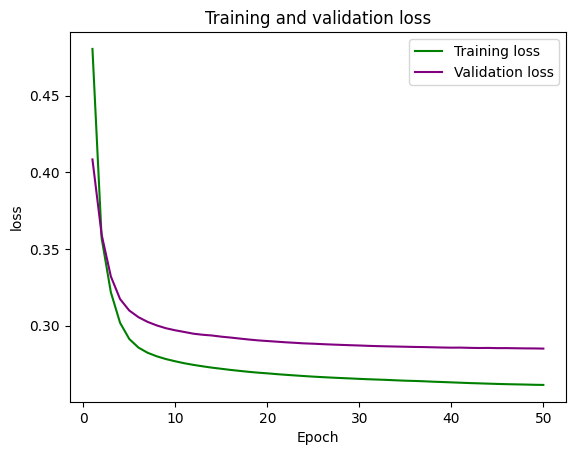

<Figure size 640x480 with 0 Axes>

In [54]:
#history
results = history.history
accuracy= results['accuracy']
val_accuracy= results['val_accuracy']
loss= results['loss']
val_loss= results['val_loss']


#loss
plt.plot(epochs,loss,"g",label="Training loss")
plt.plot(epochs,val_loss,"purple",label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.legend(loc="best")
plt.savefig(folder + "Dense_neural_network/Light_model/Train_val_loss.png")
plt.show()
plt.clf()


## 9.4 Best Model


### 9.4.1 Train - Grid Search


In [55]:
if RUN_EXPENSIVE_CELLS:

  def model_3(hp):
      inputs = Input(shape=input_shape)

      l1_param = hp.Choice("l1", [1e-4, 1e-5])
      l2_param = hp.Choice("l2", [1e-4, 1e-5])

      # Layer 1
      x = Dense(
          units=32,
          activation="relu",
          kernel_regularizer=regularizers.l1_l2(l1=l1_param, l2=l2_param)
      )(inputs)
      x = Dropout(hp.Choice("dropout_1", [0.4, 0.5]))(x)

      # Layer 2
      x = Dense(
          units=hp.Choice("units_1", [8, 16]),
          activation="relu",
          kernel_regularizer=regularizers.l1_l2(l1=l1_param, l2=l2_param)
      )(x)
      x = Dropout(hp.Choice("dropout_2", [0.3, 0.4]))(x)


      outputs = Dense(1, activation="sigmoid")(x)

      model = Model(inputs, outputs)
      model.compile(
          optimizer=Adam(learning_rate=LEARNING_RATE),
          loss="binary_crossentropy",
          metrics=["accuracy"]
      )

      return model


In [56]:
if RUN_EXPENSIVE_CELLS:

  # defining the tuner
  tuner = kt.GridSearch(
      model_3,
      objective="val_loss",
      max_trials=1000,
      directory="kt_dir",
      project_name="nn_grid"
  )


In [57]:
if RUN_EXPENSIVE_CELLS:

  tuner.search(
      X_train_processed,
      y_train,
      validation_data=(X_val_processed, y_val),
      epochs=len(epochs),
      verbose=1,
      batch_size = BATCH_SIZE,
      callbacks=[tf.keras.callbacks.EarlyStopping(
                                    monitor='val_loss',
                                    patience=4,
                                    mode='min',
                                    restore_best_weights=True,
                                    verbose=1)]
  )


### 9.4.2 Evaluate - Grid search

In [58]:
if RUN_EXPENSIVE_CELLS:

  best_model = tuner.get_best_models(num_models=1)[0]
  best_hp = tuner.get_best_hyperparameters(1)[0]

  #print(best_hp.values)


In [59]:
# Best parameters:
best_params={'l1': 1e-05, 'l2': 1e-05, 'dropout_1': 0.5, 'units_1': 8, 'dropout_2': 0.4}


In [60]:
if RUN_EXPENSIVE_CELLS:

  test_loss, test_acc = best_model.evaluate(X_test_processed, y_test)
  print(f"Loss after the test:{test_loss}\nAccuracy after the test:{test_acc}")


### 9.4.3 Re-fitting - Best parameters

In [61]:
def build_best_model(input_shape, best_params ):
    inputs = Input(shape=input_shape)


    # Layer 1
    x = Dense(
        units=32,
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(l1=best_params['l1'], l2=best_params['l2'])
    )(inputs)
    x = Dropout(best_params['dropout_1'])(x)

    # Layer 2
    x = Dense(
        units=best_params['units_1'],
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(l1=best_params['l1'], l2=best_params['l2'])
    )(x)
    x = Dropout(best_params['dropout_2'])(x)


    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [62]:

final_model = build_best_model(input_shape=input_shape, best_params=best_params)

final_model.summary()

history = final_model.fit(
    X_train_processed, y_train,
    epochs=len(epochs),
    validation_data=(X_val_processed, y_val),
    batch_size=BATCH_SIZE,

)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 593 (2.32 KB)

 Trainable params: 593 (2.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8436 - loss: 0.5014 - val_accuracy: 0.8378 - val_loss: 0.3831
Epoch 2/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8477 - loss: 0.3889 - val_accuracy: 0.8378 - val_loss: 0.3519
Epoch 3/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8512 - loss: 0.3601 - val_accuracy: 0.8573 - val_loss: 0.3325
Epoch 4/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8672 - loss: 0.3418 - val_accuracy: 0.8686 - val_loss: 0.3152
Epoch 5/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8726 - loss: 0.3250 - val_accuracy: 0.8686 - val_loss: 0.3035
Epoch 6/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8778 - loss: 0.3145 - val_accuracy: 0.8759 - val_loss: 0.2937
Epoch 7/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8852 - loss: 0.3045 - val_accuracy: 0.8783 - val_loss: 0.2888
Epoch 8/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8854 - loss: 0.2996 - val_accuracy: 0.

### 9.4.4 Evaluate - Best parameters

In [63]:
y_pred_prob = final_model.predict(X_test_processed)  # array of probabilities
y_pred = (y_pred_prob >= 0.5).astype(int)  # making predictions with the probabilities



# getting accuracy, f1-score, precision and recall and putting them in the dictionary
dense_network_standard_threshold_results['accuracy'] = accuracy_score(y_test,y_pred)
dense_network_standard_threshold_results['f1-score'] = f1_score(y_test,y_pred)
dense_network_standard_threshold_results['precision'] = precision_score(y_test,y_pred)
dense_network_standard_threshold_results['recall'] = recall_score(y_test,y_pred)

# put the results in the main dictionary
standard_threshold_results['Dense neural network']=dense_network_standard_threshold_results

print("\n\n--- RESULTS FROM DENSE NEURAL NETWORK ---")
print(f"f1-score:       {dense_network_standard_threshold_results['f1-score']:.4f}")
print(f"Precision:      {dense_network_standard_threshold_results['precision']:.4f}")
print(f"Recall:         {dense_network_standard_threshold_results['recall']:.4f}")
print(f"Accuracy :      {dense_network_standard_threshold_results['accuracy']:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


--- RESULTS FROM DENSE NEURAL NETWORK ---
f1-score:       0.5569
Precision:      0.7561
Recall:         0.4408
Accuracy :      0.8800


### 9.4.5 Learning curves

In [64]:
#get the real number of epochs (due to the earlystop)
epochs = range(1, len(history.history['loss']) + 1)


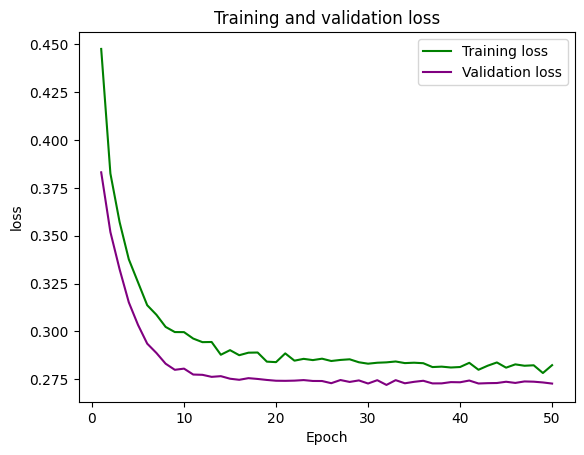

<Figure size 640x480 with 0 Axes>

In [65]:
#history
results = history.history
accuracy= results['accuracy']
val_accuracy= results['val_accuracy']
loss= results['loss']
val_loss= results['val_loss']


#loss
plt.plot(epochs,loss,"g",label="Training loss")
plt.plot(epochs,val_loss,"purple",label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.legend(loc="best")
plt.savefig(folder + "/Dense_neural_network/Best_model/Train_val_loss.png")
plt.show()
plt.clf()


### 9.4.6 Evaluate with best Threshold

In [66]:
y_probs = final_model.predict(X_test_processed).flatten()

thresholds = np.linspace(0, 1, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_score = f1_scores[best_idx]

# getting best f1-score and put in the dictionary
best_f1_score = max(f1_scores)

print("--- RESULTS FROM THRESHOLD OPTIMIZATION ---")
print(f"\nF1-score:       {dense_network_standard_threshold_results['f1-score']:.4f}    at threshold = 0.5")
print(f"Best F1-score:  {best_f1_score:.4f}    at threshold = {best_threshold:.2f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- RESULTS FROM THRESHOLD OPTIMIZATION ---

F1-score:       0.5569    at threshold = 0.5
Best F1-score:  0.6911    at threshold = 0.36


In [67]:
# Saving y_pred_best
y_pred_best = (y_probs >= best_threshold).astype(int)

# getting accuracy, f1-score, precision and recall and putting them in the dictionary
dense_network_best_threshold_results['accuracy'] = accuracy_score(y_test,y_pred_best)
dense_network_best_threshold_results['f1-score'] = f1_score(y_test,y_pred_best)
dense_network_best_threshold_results['precision'] = precision_score(y_test,y_pred_best)
dense_network_best_threshold_results['recall'] = recall_score(y_test,y_pred_best)

# put the results in the main dictionary
best_threshold_results['Dense neural network']=dense_network_best_threshold_results

print("\n\n--- RESULTS NEURAL NETWORK WITH BEST THRESHOLD ---")
print(f"f1-score:       {dense_network_best_threshold_results['f1-score']:.4f}")
print(f"Precision:      {dense_network_best_threshold_results['precision']:.4f}")
print(f"Recall:         {dense_network_best_threshold_results['recall']:.4f}")
print(f"Accuracy :      {dense_network_best_threshold_results['accuracy']:.4f}")



--- RESULTS NEURAL NETWORK WITH BEST THRESHOLD ---
f1-score:       0.6911
Precision:      0.6681
Recall:         0.7156
Accuracy :      0.8905


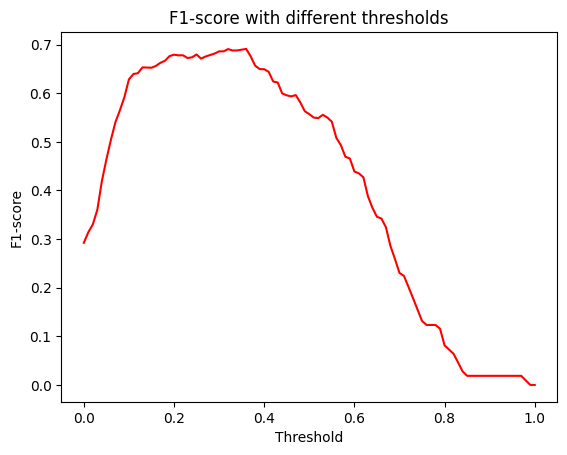

In [68]:
# Plot of the curve of the f1-score with respect to the different thresholds:
plt.plot(thresholds, f1_scores, "r")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score with different thresholds")
plt.savefig(folder+"/Dense_neural_network/Best_model/F1-score_curve.png")
plt.show()


### 9.4.7 Confusion Matrix

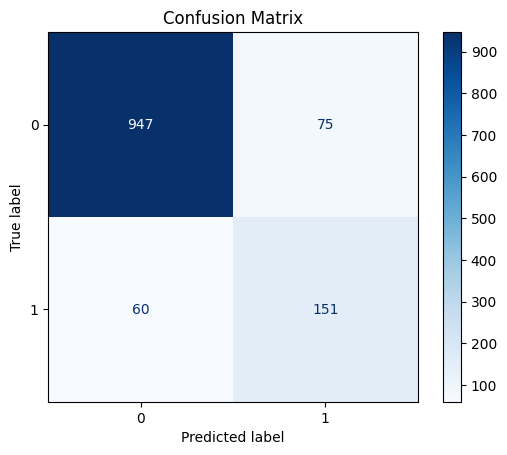

In [69]:
# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best, # using the best set of predictions
    cmap=plt.cm.Blues
)

disp.ax_.set_title("Confusion Matrix")
plt.savefig(folder+"/Dense_neural_network/Best_model/Confusion_Matrix.png")
plt.show()


# **10**. CONCLUSIONS

In [70]:
print(standard_threshold_results)
print(best_threshold_results)

{'Baseline': {'accuracy': np.float64(0.8452554744525548), 'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0}, 'Logistic Regression': {'accuracy': 0.8641524736415247, 'f1-score': 0.38979963570127507, 'precision': 0.7753623188405797, 'recall': 0.26034063260340634}, 'Decision tree': {'accuracy': 0.8791565287915653, 'f1-score': 0.6016042780748663, 'precision': 0.6676557863501483, 'recall': 0.5474452554744526}, 'Random forest': {'accuracy': 0.8807785888077859, 'f1-score': 0.4842105263157895, 'precision': 0.8679245283018868, 'recall': 0.3357664233576642}, 'Dense neural network': {'accuracy': 0.8799675587996756, 'f1-score': 0.5568862275449101, 'precision': 0.7560975609756098, 'recall': 0.44075829383886256}}
{'Baseline': {'accuracy': np.float64(0.8452554744525548), 'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0}, 'Logistic Regression': {'accuracy': 0.8661800486618005, 'f1-score': 0.6349557522123894, 'precision': 0.5821501014198783, 'recall': 0.6982968369829684}, 'Decision tree': {'accuracy': 

## 10.1 Standard Threshold

,accuracy,f1-score,precision,recall
Baseline,0.845255,0.000000,0.000000,0.000000
Logistic Regression,0.864152,0.389800,0.775362,0.260341
Decision tree,0.879157,0.601604,0.667656,0.547445
Random forest,0.880779,0.484211,0.867925,0.335766
Dense neural network,0.879968,0.556886,0.756098,0.440758


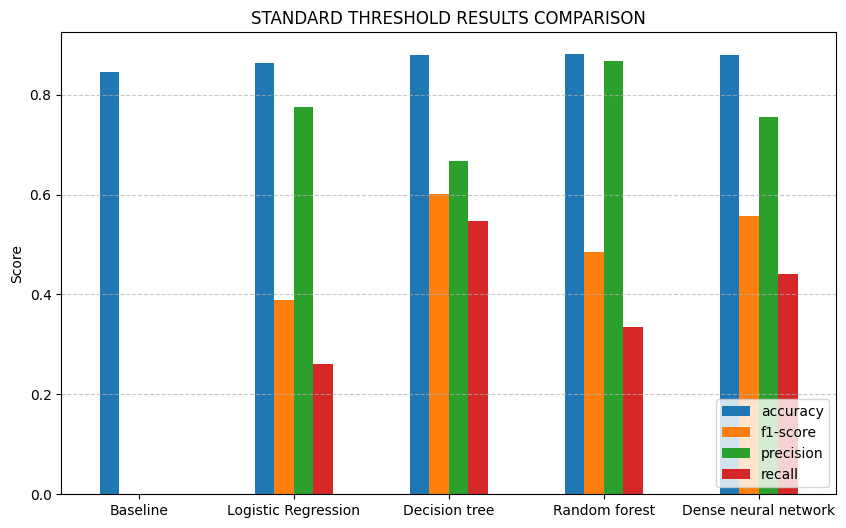

In [71]:
standard_threshold_results_df= pd.DataFrame.from_dict(standard_threshold_results, orient='index')
display(standard_threshold_results_df)


ax = standard_threshold_results_df.plot(kind='bar', figsize=(10, 6), rot=0)

plt.title("STANDARD THRESHOLD RESULTS COMPARISON")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(folder + "/Conclusions/Metrics_Comparison_standard_threshold.png")
plt.show()




## 10.2 Best Threshold

,accuracy,f1-score,precision,recall
Baseline,0.845255,0.000000,0.000000,0.000000
Logistic Regression,0.866180,0.634956,0.582150,0.698297
Decision tree,0.872263,0.674250,0.586331,0.793187
Random forest,0.877534,0.678038,0.603416,0.773723
Dense neural network,0.890511,0.691076,0.668142,0.715640


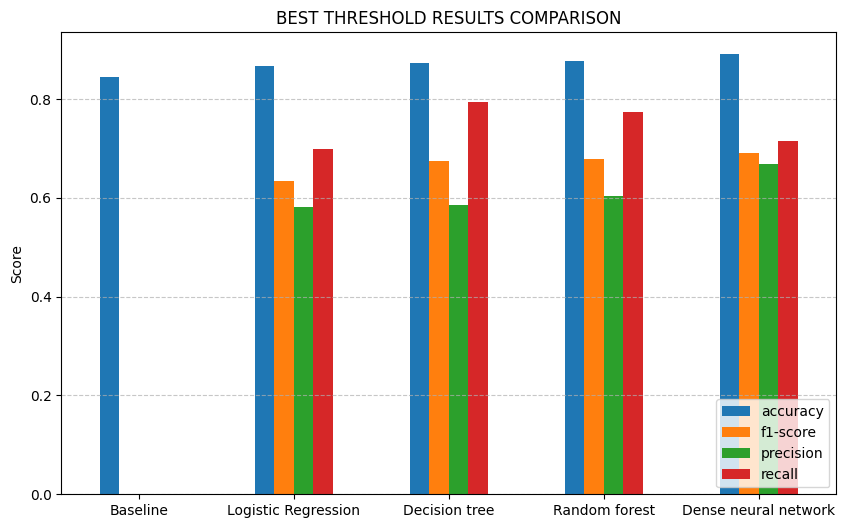

In [72]:
best_threshold_results_df= pd.DataFrame.from_dict(best_threshold_results, orient='index')
display(best_threshold_results_df)


ax = best_threshold_results_df.plot(kind='bar', figsize=(10, 6), rot=0)

plt.title("BEST THRESHOLD RESULTS COMPARISON")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(folder + "/Conclusions/Metrics_Comparison_best_threshold.png")
plt.show()


